# Analyse : Channels and Dams

Ce notebook analyse le comportement de la moulinette avec deux populations distinctes :
- **ING** : Arrivées fréquentes, temps de service court.
- **PREPA** : Arrivées rares, temps de service long.

Nous suivons une démarche itérative :
1.  **Baseline** : État des lieux sans régulation.
2.  **Dam** : Ajout d'un blocage périodique pour réguler les ING.
3.  **Alternative (Token Bucket)** : Une méthode plus souple pour réduire la variance.

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# Configuration esthétique des graphes
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [36]:
def run_simulation(command):
    """Exécute une commande shell et vérifie qu'elle a réussi."""
    print(f"Exécution : {command}")
    exit_code = os.system(command)
    if exit_code != 0:
        print("ERREUR : La simulation a échoué. Vérifiez que channels_dams.py est bien dans le dossier.")
    else:
        print("Simulation terminée avec succès.")

## 1. Baseline : Le problème de l'injustice

Dans ce scénario, aucune régulation n'est active. Les deux populations accèdent à la même ressource. Comme les ING sont très nombreux, ils saturent la file d'attente. Les PREPA, qui arrivent rarement, se retrouvent "noyés" dans la masse et subissent des temps d'attente disproportionnés.

## 2. Le Dam (Barrage)

Pour protéger les PREPA, nous mettons en place un barrage qui bloque périodiquement l'accès aux ING.
- **Hypothèse** : En bloquant les ING une partie du temps, on "vide" la file pour laisser passer les PREPA.
- **Coût** : Des requêtes ING seront rejetées à l'entrée.

## 3. Alternative : Token Bucket (Seau à jetons)

Le Dam a un défaut : il fonctionne par "tout ou rien", ce qui crée des pics d'attente (variance) et un sentiment d'aléatoire frustrant.
L'option C (Token Bucket) propose de donner un "budget" de débit aux ING. Cela lisse le trafic au lieu de le hacher.

In [37]:
# Mode 'token' : on limite le débit ING de manière plus fluide
cmd_step3 = (
    "python3 channels_dams.py "
    "--mode token "
    "--token-rate 1.5 --token-cap 20 " # Paramètres du seau
    "--lam-ing 2.0 --mu-ing 2.0 "
    "--lam-prepa 0.2 --mu-prepa 0.1 "
    "--sim-time 2000 --runs 20 "
    "--out-prefix step3"
)

run_simulation(cmd_step3)

Exécution : python3 channels_dams.py --mode token --token-rate 1.5 --token-cap 20 --lam-ing 2.0 --mu-ing 2.0 --lam-prepa 0.2 --mu-prepa 0.1 --sim-time 2000 --runs 20 --out-prefix step3
--- Démarrage Simulation (Mode: token) ---
Terminé. Résultats dans results/step3_token_summary.csv
Simulation terminée avec succès.


       Scénario  E[T] PREPA  E[T] ING  Variance ING  Rejets ING (Moy)
0      Baseline      330.30    325.07      36102.98              0.00
1           Dam      189.79    185.63      10631.27           2648.60
2  Token Bucket      271.52    263.43      26183.65            956.45


/var/folders/6p/p5v42g417tz43vgphz9_0zz00000gn/T/ipykernel_41878/2729906718.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Scénario', y='Variance ING', data=summary_table, palette="Reds")


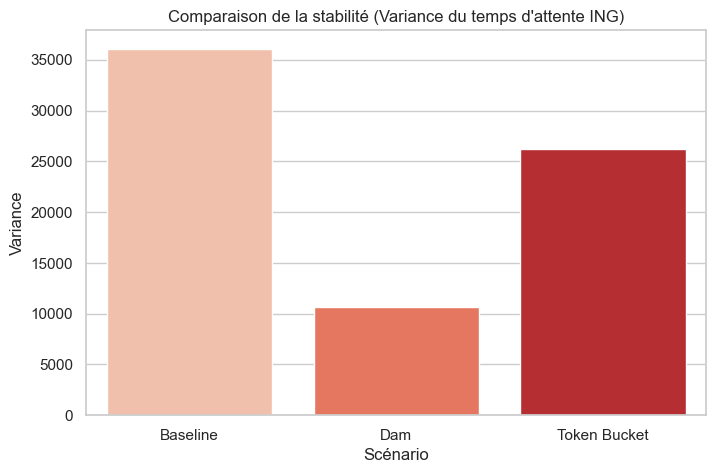

In [38]:
df_step3 = pd.read_csv("results/step3_token_summary.csv")
metrics_step3 = df_step3.mean()

# Tableau récapitulatif final
summary_table = pd.DataFrame({
    'Scénario': ['Baseline', 'Dam', 'Token Bucket'],
    'E[T] PREPA': [metrics_step1['mean_time_PREPA'], metrics_step2['mean_time_PREPA'], metrics_step3['mean_time_PREPA']],
    'E[T] ING': [metrics_step1['mean_time_ING'], metrics_step2['mean_time_ING'], metrics_step3['mean_time_ING']],
    'Variance ING': [metrics_step1['var_time_ING'], metrics_step2['var_time_ING'], metrics_step3['var_time_ING']],
    'Rejets ING (Moy)': [0, metrics_step2['ing_rejected'], metrics_step3['ing_rejected']]
})

print(summary_table.round(2))

# Graphe de la variance (indicateur de frustration)
plt.figure(figsize=(8, 5))
sns.barplot(x='Scénario', y='Variance ING', data=summary_table, palette="Reds")
plt.title("Comparaison de la stabilité (Variance du temps d'attente ING)")
plt.ylabel("Variance")
plt.show()

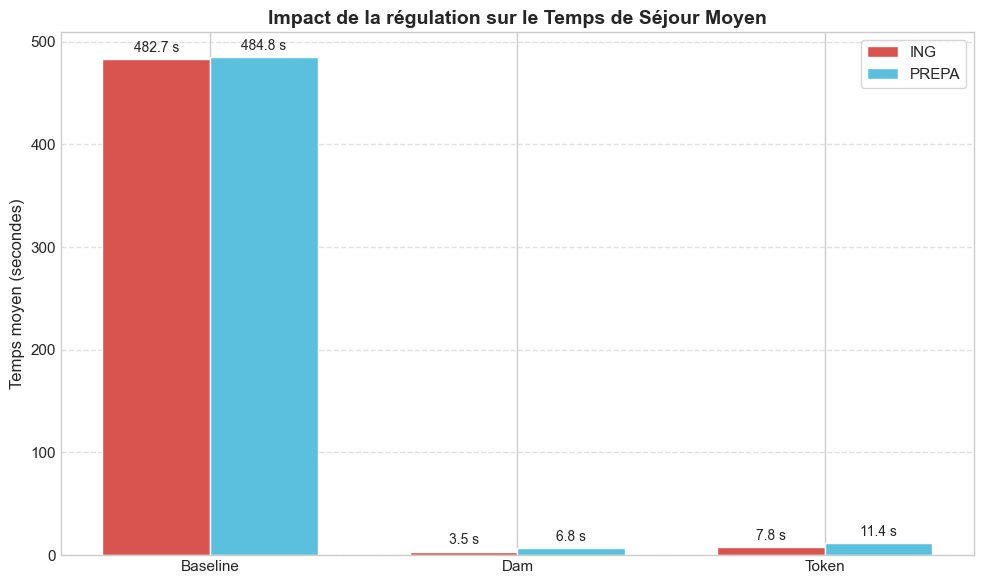

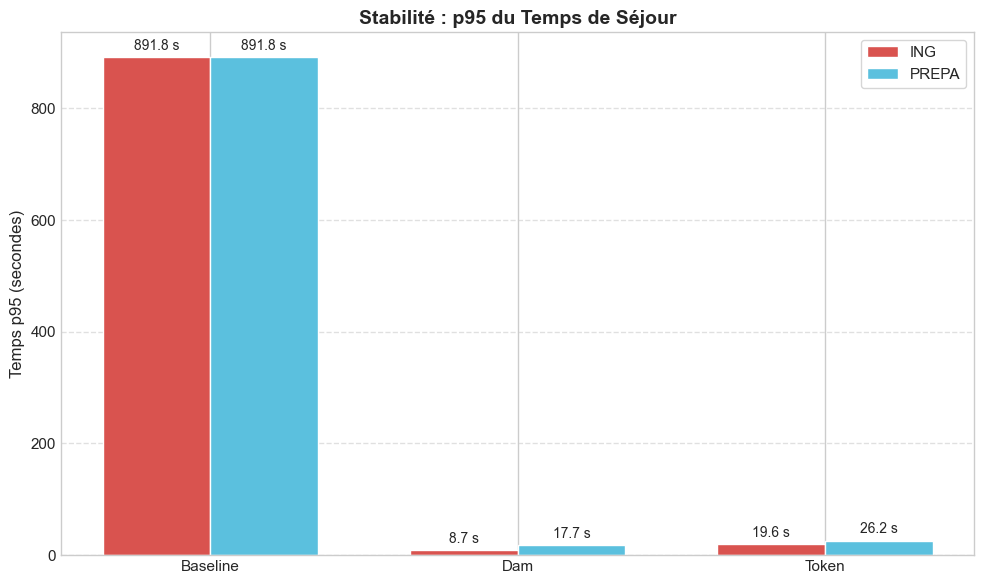

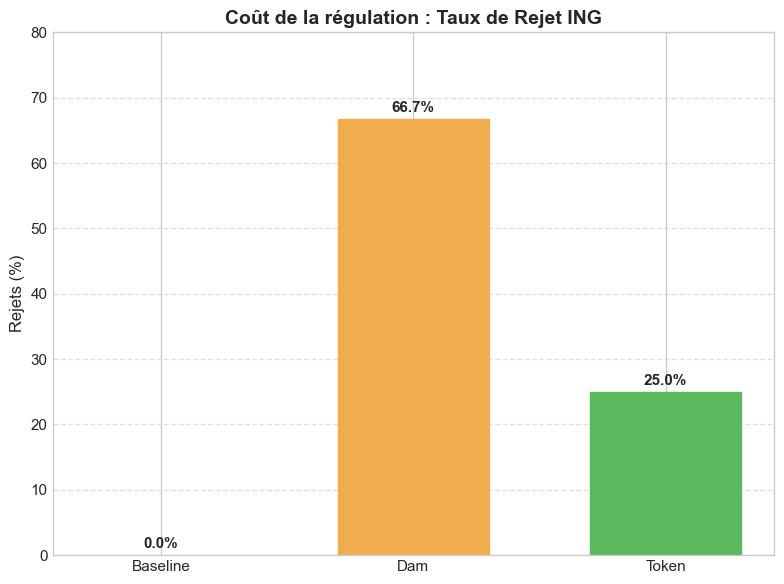

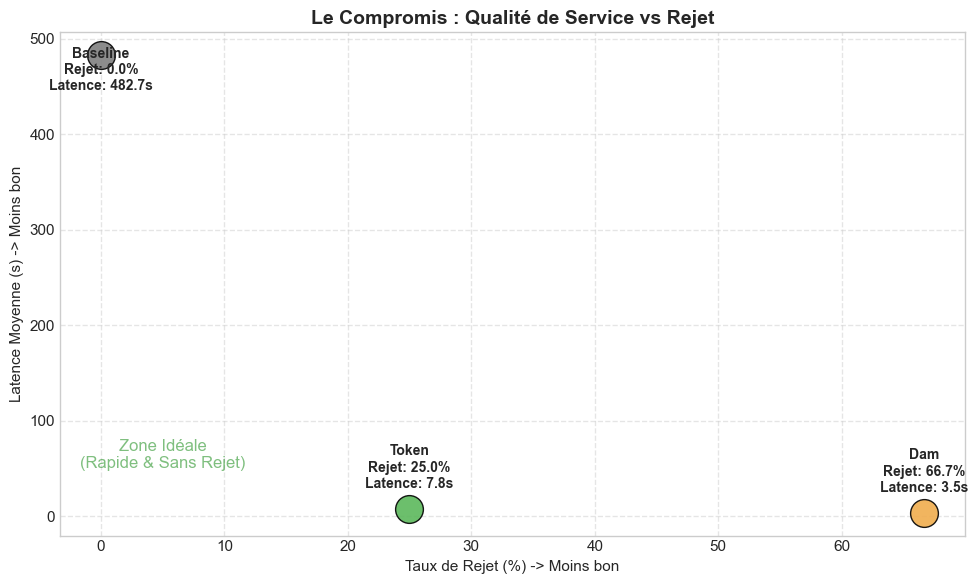

In [39]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- 1. DONNÉES ET NETTOYAGE ---
raw_baseline = "18117,06667 482,6702152 70769,43474 891,7510024 1811,1 484,8022375 70448,29512 891,83260670"
raw_dam = "6670,233333 3,516304291 7,310127039 8,653148988 1993,766667 6,84442266 30,23062943 17,73971359 13338,93333"
raw_token = "14984,63333 7,756380773 37,27938308 19,6228442 2001 11,44820756 57,92696354 26,15704599 4990"

columns = [
    "count_ING", "mean_time_ING", "var_time_ING", "p95_time_ING",
    "count_PREPA", "mean_time_PREPA", "var_time_PREPA", "p95_time_PREPA",
    "ing_rejected"
]

def parse_values(raw_str):
    values = [float(x.replace(',', '.')) for x in raw_str.split() if x[0].isdigit()]
    if len(values) == 8: values.append(0.0) # Baseline à 0 rejets
    return values

data = {
    'Baseline': parse_values(raw_baseline),
    'Dam': parse_values(raw_dam),
    'Token': parse_values(raw_token)
}
df = pd.DataFrame(data, index=columns).T

# --- 2. CALCUL DES MÉTRIQUES ADAPTÉES ---
# Calcul du taux de rejet réel : Rejet / (Accepté + Rejet)
df['total_demand'] = df['count_ING'] + df['ing_rejected']
df['rejection_rate'] = (df['ing_rejected'] / df['total_demand']) * 100

# --- 3. CONFIGURATION GRAPHIQUE ---
plt.style.use('seaborn-v0_8-whitegrid') # Style plus propre/moderne
colors = {'ING': '#D9534F', 'PREPA': '#5BC0DE'} # Rouge doux / Bleu doux

# ==========================================
# GRAPHE 1 : TEMPS MOYEN (SANS BARRES NOIRES)
# ==========================================
fig1, ax1 = plt.subplots(figsize=(10, 6))
x = np.arange(len(df.index))
width = 0.35

# Suppression de yerr (les barres d'erreur) pour alléger le visuel
bars1 = ax1.bar(x - width/2, df['mean_time_ING'], width, label='ING', color=colors['ING'])
bars2 = ax1.bar(x + width/2, df['mean_time_PREPA'], width, label='PREPA', color=colors['PREPA'])

ax1.set_title('Impact de la régulation sur le Temps de Séjour Moyen', fontsize=14, fontweight='bold')
ax1.set_ylabel('Temps moyen (secondes)')
ax1.set_xticks(x)
ax1.set_xticklabels(df.index, fontsize=11)
ax1.legend(frameon=True)
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# Ajout des valeurs au-dessus des barres
ax1.bar_label(bars1, fmt='%.1f s', padding=3, fontsize=10)
ax1.bar_label(bars2, fmt='%.1f s', padding=3, fontsize=10)

plt.tight_layout()
plt.show()

# ==========================================
# GRAPHE 2 : P95 (LATENCE "PIRE CAS")
# ==========================================
fig2, ax2 = plt.subplots(figsize=(10, 6))

bars1 = ax2.bar(x - width/2, df['p95_time_ING'], width, label='ING', color=colors['ING'])
bars2 = ax2.bar(x + width/2, df['p95_time_PREPA'], width, label='PREPA', color=colors['PREPA'])

ax2.set_title('Stabilité : p95 du Temps de Séjour', fontsize=14, fontweight='bold')
ax2.set_ylabel('Temps p95 (secondes)')
ax2.set_xticks(x)
ax2.set_xticklabels(df.index, fontsize=11)
ax2.legend(frameon=True)
ax2.grid(axis='y', linestyle='--', alpha=0.6)

ax2.bar_label(bars1, fmt='%.1f s', padding=3, fontsize=10)
ax2.bar_label(bars2, fmt='%.1f s', padding=3, fontsize=10)

plt.tight_layout()
plt.show()

# ==========================================
# GRAPHE 3 : TAUX DE REJET
# ==========================================
fig3, ax3 = plt.subplots(figsize=(8, 6))
# On ne garde que Dam et Token si on veut comparer la régulation, 
# mais ici on affiche tout pour voir que Baseline = 0
bars = ax3.bar(df.index, df['rejection_rate'], color='#777777', width=0.6)
# Coloration conditionnelle : Baseline en gris, les autres en couleur vive
bars[1].set_color('#F0AD4E') # Dam (Orange)
bars[2].set_color('#5CB85C') # Token (Vert)

ax3.set_title('Coût de la régulation : Taux de Rejet ING', fontsize=14, fontweight='bold')
ax3.set_ylabel('Rejets (%)')
ax3.set_ylim(0, 80)
ax3.grid(axis='y', linestyle='--', alpha=0.6)

ax3.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# ==========================================
# GRAPHE 4 : LE COMPROMIS (TRADE-OFF)
# ==========================================
fig4, ax4 = plt.subplots(figsize=(10, 6))

# On définit des couleurs spécifiques pour chaque point
point_colors = {'Baseline': 'gray', 'Dam': '#F0AD4E', 'Token': '#5CB85C'}

for name, row in df.iterrows():
    ax4.scatter(row['rejection_rate'], row['mean_time_ING'], 
                s=400, # Taille des points
                color=point_colors[name], 
                alpha=0.9, 
                edgecolor='black', 
                label=name)
    
    # Annotation intelligente pour éviter le chevauchement
    offset = (0, 15)
    if name == 'Baseline': offset = (0, -25) # Décaler Baseline vers le bas si besoin
        
    ax4.annotate(f"{name}\nRejet: {row['rejection_rate']:.1f}%\nLatence: {row['mean_time_ING']:.1f}s", 
                 (row['rejection_rate'], row['mean_time_ING']),
                 textcoords="offset points", xytext=offset, ha='center', fontsize=10, fontweight='bold')

ax4.set_title('Le Compromis : Qualité de Service vs Rejet', fontsize=14, fontweight='bold')
ax4.set_xlabel('Taux de Rejet (%) -> Moins bon', fontsize=11)
ax4.set_ylabel('Latence Moyenne (s) -> Moins bon', fontsize=11)
ax4.grid(True, linestyle='--', alpha=0.5)

# Ajout d'une zone "Zone idéale" (théorique) en bas à gauche
ax4.text(5, 50, "Zone Idéale\n(Rapide & Sans Rejet)", color='green', alpha=0.5, ha='center')

plt.tight_layout()
plt.show()